#**🚗 CAR SALES DATA ANALYSIS WITH PYTHON**

##1️⃣ Import Library

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)

##2️⃣ Load & Inspect Data

In [3]:
df = pd.read_excel("Car Sales.xlsx")

# Preview data
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [4]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Car_id         23906 non-null  object        
 1   Date           23906 non-null  datetime64[ns]
 2   Customer Name  23905 non-null  object        
 3   Gender         23906 non-null  object        
 4   Annual Income  23906 non-null  int64         
 5   Dealer_Name    23906 non-null  object        
 6   Company        23906 non-null  object        
 7   Model          23906 non-null  object        
 8   Engine         23906 non-null  object        
 9   Transmission   23906 non-null  object        
 10  Color          23906 non-null  object        
 11  Price ($)      23906 non-null  int64         
 12  Dealer_No      23906 non-null  object        
 13  Body Style     23906 non-null  object        
 14  Phone          23906 non-null  int64         
 15  Dealer_Region  2390

In [5]:
# Column names
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

##3️⃣ Data Cleaning & Preprocessing

In [6]:
df = df.rename(columns={
    'Price ($)': 'price',
    'Annual Income': 'annual_income',
    'Dealer_Region': 'dealer_region',
    'Body Style': 'body_style'
})

In [7]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'annual_income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'price', 'Dealer_No ', 'body_style', 'Phone', 'dealer_region'],
      dtype='object')

In [8]:
# Data Type Conversion
df['Date'] = pd.to_datetime(df['Date'])
df['price'] = df['price'].astype(float)
df['annual_income'] = df['annual_income'].astype(float)

In [9]:
# Missing Values Check
df.isna().sum()

,0
Car_id,0
Date,0
Customer Name,1
Gender,0
annual_income,0
Dealer_Name,0
Company,0
Model,0
Engine,0
Transmission,0


##4️⃣ Feature Engineering

In [10]:
# Date features
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['month_name'] = df['Date'].dt.month_name()
df['week'] = df['Date'].dt.isocalendar().week

# Income segmentation
df['income_segment'] = pd.cut(
    df['annual_income'],
    bins=[0, 50000, 100000, 500000, np.inf],
    labels=['Low', 'Mid', 'Upper Mid', 'High']
)

##5️⃣ Exploratory Data Analysis (EDA)

In [11]:
# Overall Sales Performance
total_sales = df['price'].sum()
avg_price = df['price'].mean()
total_cars = df.shape[0]

total_sales, avg_price, total_cars

(np.float64(671525465.0), np.float64(28090.247845729107), 23906)

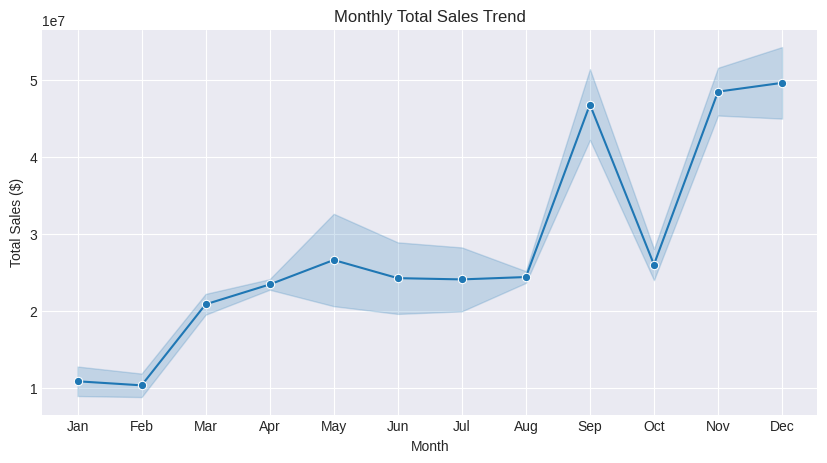

In [12]:
# Sales Trend Over Time

monthly_sales = (
    df.groupby(['year', 'month'])['price']
      .sum()
      .reset_index()
)

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='price',
    marker='o'
)

plt.title("Monthly Total Sales Trend")
plt.ylabel("Total Sales ($)")
plt.xlabel("Month")
plt.xticks(
    ticks=range(1, 13),
    labels=[
        'Jan','Feb','Mar','Apr','May','Jun',
        'Jul','Aug','Sep','Oct','Nov','Dec'
    ]
)
plt.show()

In [13]:
# Sales by Body Style
body_style_sales = (
    df.groupby('body_style')
      .agg(
          total_sales=('price', 'sum'),
          cars_sold=('price', 'count'),
          avg_price=('price', 'mean')
      )
      .sort_values('total_sales', ascending=False)
)

body_style_sales

,total_sales,cars_sold,avg_price
body_style,,,
SUV,170617149.0,6374,26767.673204
Hatchback,166234474.0,6128,27127.035574
Sedan,133889619.0,4488,29832.802807
Passenger,114176315.0,3945,28942.031686
Hardtop,86607908.0,2971,29151.096600


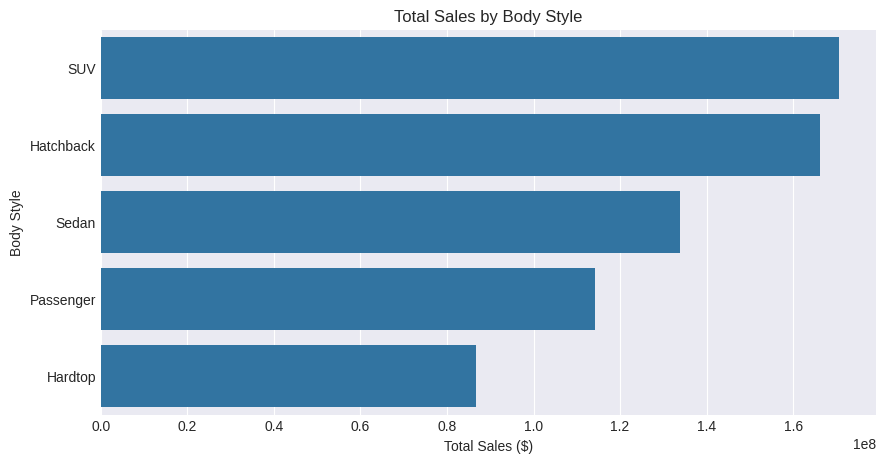

In [14]:
sns.barplot(
    data=body_style_sales.reset_index(),
    x='total_sales',
    y='body_style'
)
plt.title("Total Sales by Body Style")
plt.xlabel("Total Sales ($)")
plt.ylabel("Body Style")
plt.show()

In [15]:
# Sales by Company (Brand Performance)
company_sales = (
    df.groupby('Company')['price']
      .sum()
      .sort_values(ascending=False)
)

company_sales.head(10)

,price
Company,
Chevrolet,47655265.0
Ford,47231583.0
Dodge,44124996.0
Oldsmobile,35434512.0
Mercedes-B,34624123.0
Volkswagen,34082881.0
Mitsubishi,34062466.0
Toyota,32759564.0
Chrysler,29141873.0


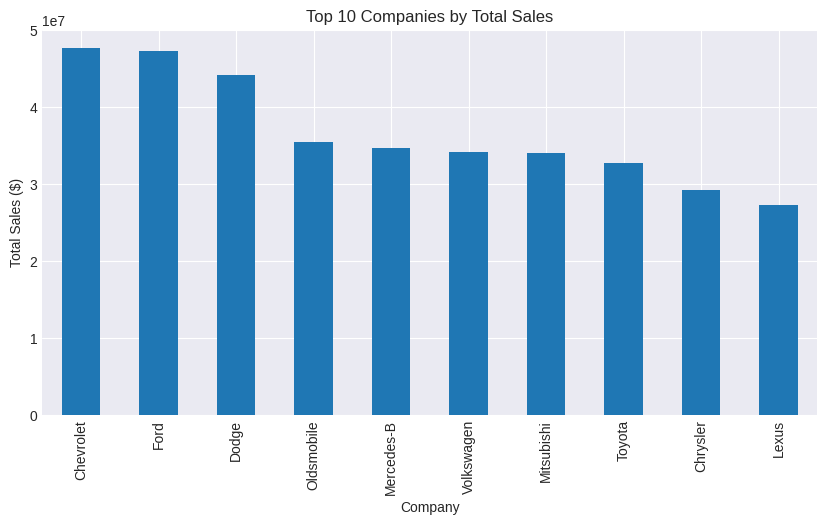

In [16]:
company_sales.head(10).plot(
    kind='bar',
    title='Top 10 Companies by Total Sales'
)
plt.ylabel("Total Sales ($)")
plt.show()

In [17]:
# Dealer Region Analysis
region_sales = (
    df.groupby('dealer_region')['price']
      .sum()
      .sort_values(ascending=False)
)

region_sales

,price
dealer_region,
Austin,117192531.0
Janesville,106351234.0
Scottsdale,95969374.0
Aurora,88687382.0
Greenville,88149602.0
Pasco,88040714.0
Middletown,87134628.0


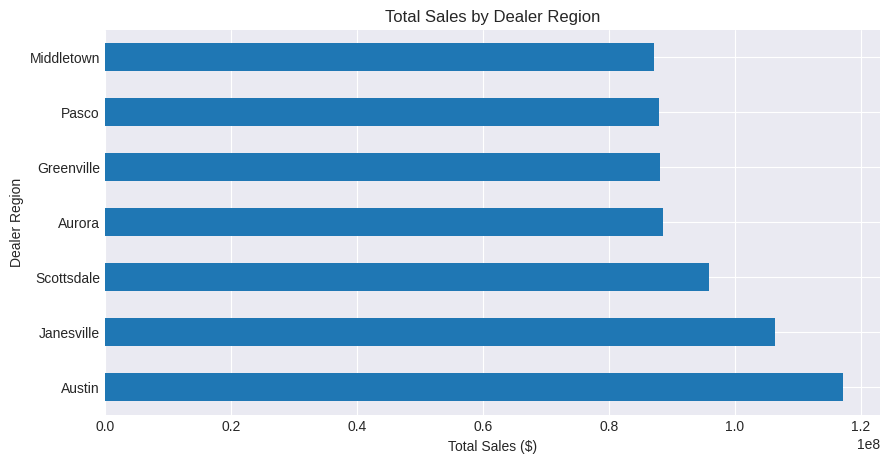

In [18]:
region_sales.plot(
    kind='barh',
    title='Total Sales by Dealer Region'
)
plt.xlabel("Total Sales ($)")
plt.ylabel("Dealer Region")
plt.show()

In [19]:
# Transmission Preference
transmission_sales = (
    df.groupby('Transmission')['price']
      .agg(['count', 'mean'])
      .rename(columns={'count':'cars_sold', 'mean':'avg_price'})
)

transmission_sales

,cars_sold,avg_price
Transmission,,
Auto,12571,28248.525972
Manual,11335,27914.710631


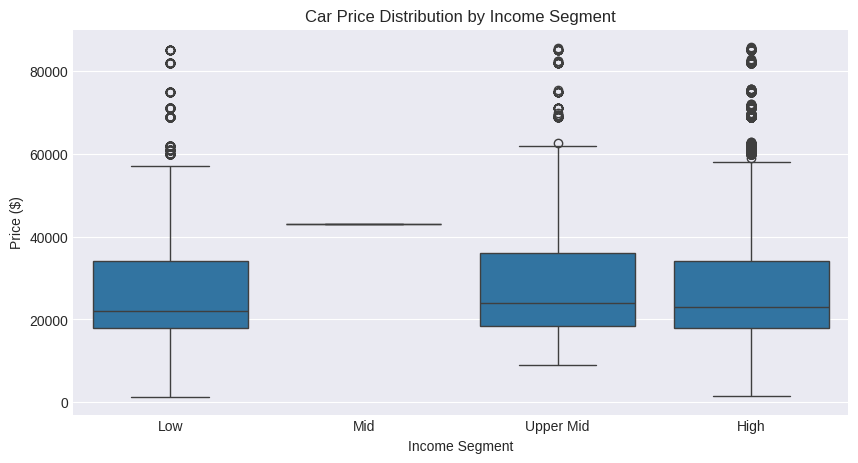

In [20]:
# Income vs Price Analysis
sns.boxplot(
    data=df,
    x='income_segment',
    y='price'
)
plt.title("Car Price Distribution by Income Segment")
plt.xlabel("Income Segment")
plt.ylabel("Price ($)")
plt.show()

In [21]:
# Color Preference
color_sales = (
    df.groupby('Color')['price']
      .count()
      .sort_values(ascending=False)
)

color_sales.head(10)

,price
Color,
Pale White,11256
Black,7857
Red,4793


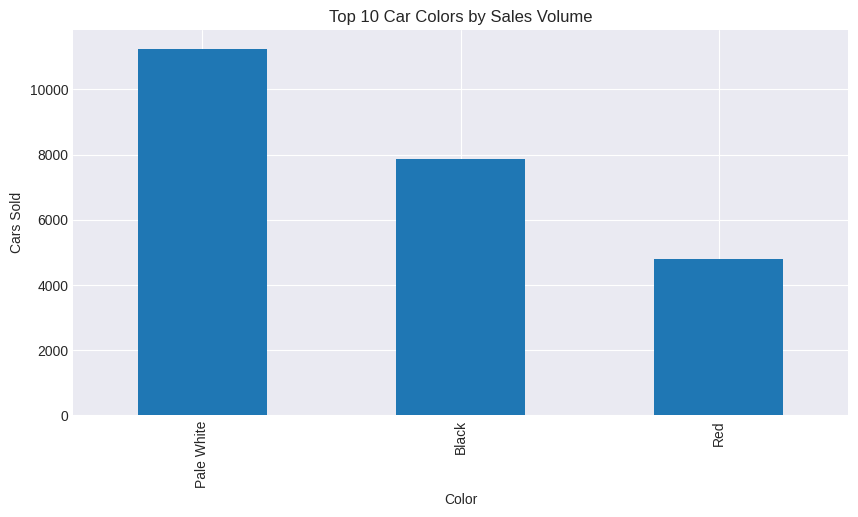

In [22]:
color_sales.head(10).plot(
    kind='bar',
    title='Top 10 Car Colors by Sales Volume'
)
plt.ylabel("Cars Sold")
plt.show()

# 📊 Car Sales Data Analysis – Final Insights & Recommendations

## 1. Overall Sales Performance
- Total sales menunjukkan pola **musiman yang kuat**, dengan puncak penjualan terjadi pada **akhir tahun (Q4)**.
- Penurunan penjualan terlihat pada **awal tahun (January–March)**, yang mengindikasikan periode demand rendah.
- Lonjakan penjualan di bulan **November dan December** kemungkinan dipengaruhi oleh promosi akhir tahun dan peningkatan daya beli konsumen.

**Recommendation:**
- Fokuskan stok dan kampanye promosi pada Q4 untuk memaksimalkan revenue.
- Terapkan strategi promosi khusus di awal tahun (diskon, cicilan ringan, atau cashback) untuk menjaga stabilitas penjualan.

---

## 2. Body Style Performance
- **SUV** menjadi kontributor terbesar terhadap total penjualan.
- Diikuti oleh **Hatchback** dan **Sedan** sebagai penopang volume penjualan.
- **Hardtop** dan **Passenger cars** memiliki kontribusi relatif lebih kecil.

**Insight:**
- SUV berperan sebagai **revenue driver utama** karena harga rata-rata yang lebih tinggi dan preferensi konsumen terhadap kendaraan multifungsi.

**Recommendation:**
- Prioritaskan SUV sebagai produk utama.
- Manfaatkan Hatchback dan Sedan untuk strategi volume melalui promosi harga.
- Posisikan Hardtop sebagai produk niche dengan target market tertentu.

---

## 3. Company (Brand) Performance
- Brand dengan total penjualan tertinggi:
  - Chevrolet
  - Ford
  - Dodge
- Selisih penjualan antar brand teratas relatif kecil, menunjukkan **persaingan yang ketat**.

**Insight:**
- Brand mass-market mendominasi total revenue dibandingkan brand premium.

**Recommendation:**
- Dealer dapat memprioritaskan brand dengan turnover tinggi.
- Brand premium dapat dioptimalkan melalui strategi upselling dan bundling untuk meningkatkan margin.

---

## 4. Regional Performance
- Dealer region dengan performa terbaik:
  - Austin
  - Janesville
  - Scottsdale
- Terdapat perbedaan performa yang cukup signifikan antar region.

**Insight:**
- Beberapa region memiliki potensi optimalisasi yang belum maksimal.

**Recommendation:**
- Replikasi strategi penjualan dari region dengan performa terbaik.
- Terapkan pendekatan pemasaran berbasis karakteristik regional.
- Evaluasi dealer underperform untuk perbaikan distribusi dan stok.

---

## 5. Transmission Preference
- Mobil dengan **Automatic transmission** terjual lebih banyak dibanding Manual.
- Harga rata-rata mobil Automatic juga sedikit lebih tinggi.

**Insight:**
- Konsumen menunjukkan preferensi kuat terhadap kenyamanan dan kemudahan penggunaan.

**Recommendation:**
- Tingkatkan stok mobil Automatic, khususnya untuk SUV dan Sedan.
- Manual transmission dapat difokuskan untuk segmen harga sensitif atau kebutuhan tertentu.

---

## 6. Color Preference
- Warna paling diminati:
  1. Pale White
  2. Black
  3. Red

**Insight:**
- Konsumen cenderung memilih warna netral dibandingkan warna mencolok.

**Recommendation:**
- Pastikan ketersediaan warna netral sebagai stok utama.
- Gunakan warna mencolok untuk edisi terbatas atau strategi diferensiasi pemasaran.

---

## 7. Customer Income Behavior
- Segmen **Mid dan Upper-Mid income** menyumbang volume penjualan terbesar.
- Segmen **High-income** memiliki nilai transaksi lebih tinggi tetapi volume lebih kecil.

**Recommendation:**
- Targetkan Mid-income segment untuk pertumbuhan volume.
- Tawarkan fitur tambahan dan paket premium untuk High-income segment guna meningkatkan margin.

---

## Executive Summary
Analisis menunjukkan bahwa SUV, Automatic transmission, dan brand mass-market merupakan pendorong utama pendapatan. Pola musiman yang kuat di akhir tahun membuka peluang optimalisasi stok dan promosi, sementara perbedaan performa antar region menunjukkan potensi peningkatan melalui strategi lokal yang lebih terarah.